In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3D projection)
import iadpython as iad

In [2]:
def adaptive_quadtree_sample(
    f,
    x0,
    x1,
    y0,
    y1,
    tol=5e-3,
    max_depth=8,
    *,  # keyword-only from here
    min_depth=0,  # depth guarantee (0 ⇒ disabled)
    init_grid=0,  # pre-sample N×N lattice (0 ⇒ disabled)
):
    """
    Adaptive quadtree sampler (corner + centre test) with two base-grid options.

    Parameters
    ----------
    f : callable
        Function of two variables (x, y).
    x0, x1, y0, y1 : float
        Domain bounds.
    tol : float, default 5e-3
        Subdivide a cell when the local interpolation error > tol.
    max_depth : int, default 8
        Hard limit on quadtree depth.
    min_depth : int, optional
        Force subdivision until this depth before using the error test.
        (depth 3 ⇒ 8×8 base mesh.)
    init_grid : int, optional
        If >1, pre-sample a uniform init_grid × init_grid lattice before the
        adaptive loop (works for any size, e.g. 10 for a 10×10 base).

    Returns:
    -------
    samples : list[(x, y, f)]
        Unique sample points with their function value.
    """
    # ---------------------------------------------------------------
    # helpers & storage
    # ---------------------------------------------------------------
    stack = [((x0, x1, y0, y1), 0)]  # (bounds, depth)
    cache, out = {}, []

    def eval_f(x, y):
        """Memoised evaluation."""
        if (x, y) not in cache:
            cache[(x, y)] = f(x, y)
            out.append((x, y, cache[(x, y)]))
        return cache[(x, y)]

    # ---------------------------------------------------------------
    # optional uniform pre-grid
    # ---------------------------------------------------------------
    if init_grid > 1:
        xs = np.linspace(x0, x1, init_grid)
        ys = np.linspace(y0, y1, init_grid)
        for xi in xs:
            for yi in ys:
                eval_f(xi, yi)  # duplicates ignored

    # ---------------------------------------------------------------
    # main adaptive loop
    # ---------------------------------------------------------------
    while stack:
        (xa, xb, ya, yb), depth = stack.pop()
        xm, ym = 0.5 * (xa + xb), 0.5 * (ya + yb)

        # four corners + centre
        f00 = eval_f(xa, ya)
        f10 = eval_f(xb, ya)
        f01 = eval_f(xa, yb)
        f11 = eval_f(xb, yb)
        fcc = eval_f(xm, ym)

        # bilinear interpolation of centre from corners
        interp = 0.25 * (f00 + f10 + f01 + f11)
        err = abs(fcc - interp)

        need_split = (depth < min_depth) or (err > tol and depth < max_depth)
        if need_split:
            d = depth + 1
            stack.extend(
                [
                    ((xa, xm, ya, ym), d),
                    ((xm, xb, ya, ym), d),
                    ((xa, xm, ym, yb), d),
                    ((xm, xb, ym, yb), d),
                ]
            )

    return out

### demo -------------------------------------------------------------

In [3]:
def f(x, y):
    """Synthetic test surface with both smooth & steep regions."""
    return np.sin(3 * np.pi * x) * np.cos(3 * np.pi * y) * np.exp(-((x - 0.5) ** 2 + (y - 0.5) ** 2) / 0.1)

### Create a regular grid of points and plot

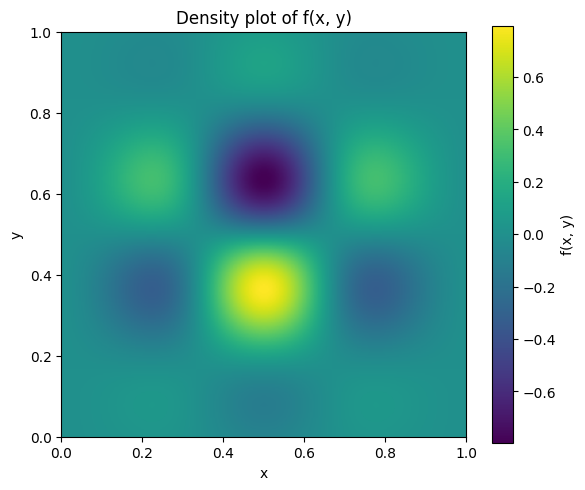

In [4]:
n = 300
x = np.linspace(0.0, 1.0, n)
y = np.linspace(0.0, 1.0, n)
X, Y = np.meshgrid(x, y, indexing="xy")
Z = f(X, Y)

plt.figure(figsize=(6, 5))
plt.imshow(Z, extent=[0, 1, 0, 1], origin="lower", aspect="equal")
plt.title("Density plot of f(x, y)")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(label="f(x, y)")
plt.tight_layout()
plt.show()

### Three‑dimensional surface plot


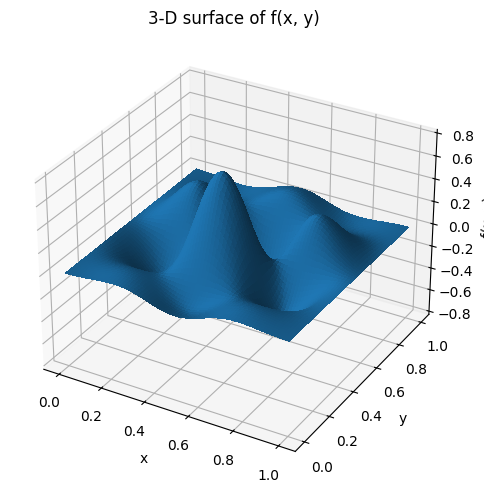

In [5]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

# Using a modest stride keeps rendering fast while respecting the no‑color rule
stride = 4
ax.plot_surface(X, Y, Z, rstride=stride, cstride=stride, linewidth=0, antialiased=False)

ax.set_title("3‑D surface of f(x, y)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
fig.tight_layout()
plt.show()

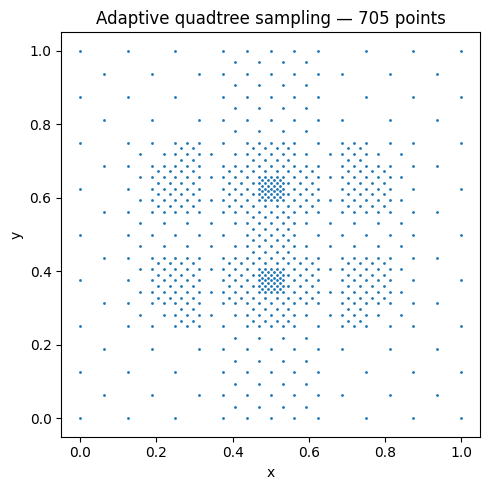

In [6]:
# run the sampler
samples = adaptive_quadtree_sample(
    f,
    0.0,
    1.0,
    0.0,
    1.0,
    tol=0.02,
    max_depth=7,
    min_depth=3,  # guarantees an 8×8 base mesh ≈ your 10×10 wish
    # OR use init_grid=10 if you want exactly 10×10 before refinement
)

# unpack for plotting
xs = [p[0] for p in samples]
ys = [p[1] for p in samples]

plt.figure(figsize=(5, 5))
plt.scatter(xs, ys, s=1)  # default colour
plt.title(f"Adaptive quadtree sampling — {len(samples)} points")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [7]:
sample = iad.Sample(a=0.9, b=10, g=0.9, n=1.5, quad_pts=4)
ur1, ut1, uru, utu = sample.rt()
print(ur1)
print(ut1)

0.06521054751657043
0.11213012147479617


In [8]:
def adrt_scalar(a, b):
    """Example function with both smooth and sharp features."""
    sample = iad.Sample(a=a, b=b, g=0.9, n=1.5, quad_pts=4)
    ur1, ut1, _, _ = sample.rt()
    return ur1 + ut1


adrt_vec = np.vectorize(adrt_scalar, otypes=[float])

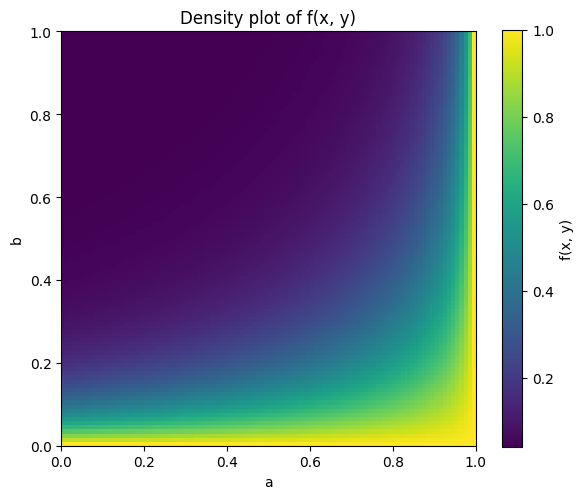

In [9]:
n = 100
a = np.linspace(0.0, 1.0, n)
b = np.linspace(0.0, 10, n)
A, B = np.meshgrid(a, b, indexing="xy")
Z = adrt_vec(A, B)

plt.figure(figsize=(6, 5))
plt.imshow(Z, extent=[0, 1, 0, 1], origin="lower", aspect="equal")
plt.title("Density plot of f(x, y)")
plt.xlabel("a")
plt.ylabel("b")
plt.colorbar(label="f(x, y)")
plt.tight_layout()
plt.show()

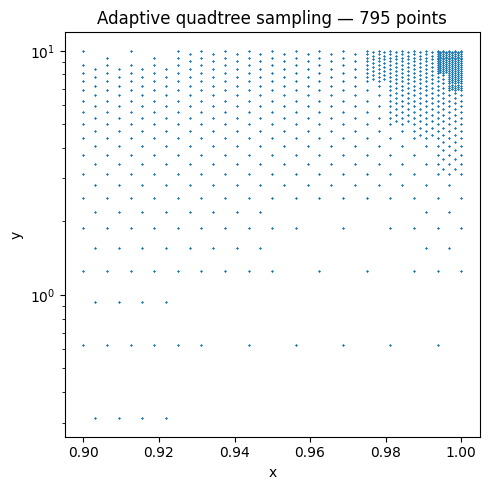

In [10]:
# run the sampler
samples = adaptive_quadtree_sample(
    adrt_scalar,
    0.9,
    1.0,
    0.0,
    10,
    tol=0.002,
    max_depth=8,
    min_depth=3,  # guarantees an 8×8 base mesh ≈ your 10×10 wish
    # OR use init_grid=10 if you want exactly 10×10 before refinement
)

# unpack for plotting
xs = [p[0] for p in samples]
ys = [p[1] for p in samples]

plt.figure(figsize=(5, 5))
plt.semilogy(xs, ys, "x", markersize=1)  # default colour
plt.title(f"Adaptive quadtree sampling — {len(samples)} points")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()